In [1]:
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import os

/home/ec2-user/miniforge3/envs/spatial/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
table_dir = os.path.expanduser("../results/tables")
figure_dir = os.path.expanduser("../results/figures") 

In [3]:
adata = sc.read_h5ad(os.path.expanduser(
    "../data/processed/05_deconvolved.h5ad"))

In [4]:
if "spatial_connectivities" not in adata.obsp:
    sq.gr.spatial_neighbors(adata, coord_type="grid", n_neighs=6)

In [5]:
# Neighborhood Enrichment
# ground truth
sq.gr.nhood_enrichment(adata, cluster_key="ground_truth")

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
sq.pl.nhood_enrichment(
    adata, cluster_key="ground_truth",
    method="average",
    figsize=(8, 8), ax=ax,
    title="Neighborhood Enrichment\n(Ground Truth Layers)"
)
plt.tight_layout()
plt.savefig(os.path.join(figure_dir, "nhood_enrichment_gt.png"),
            dpi=200, bbox_inches='tight')
plt.close()

100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 3291.78/s]


In [7]:
# BayesSpace
sq.gr.nhood_enrichment(adata, cluster_key="bayesspace")

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
sq.pl.nhood_enrichment(
    adata, cluster_key="bayesspace",
    method="average",
    figsize=(8, 8), ax=ax,
    title="Neighborhood Enrichment\n(BayesSpace)"
)
plt.tight_layout()
plt.savefig(os.path.join(figure_dir, "nhood_enrichment_bayesspace.png"),
            dpi=200, bbox_inches='tight')
plt.close()

100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 3293.78/s]


<Figure size 1400x1200 with 0 Axes>

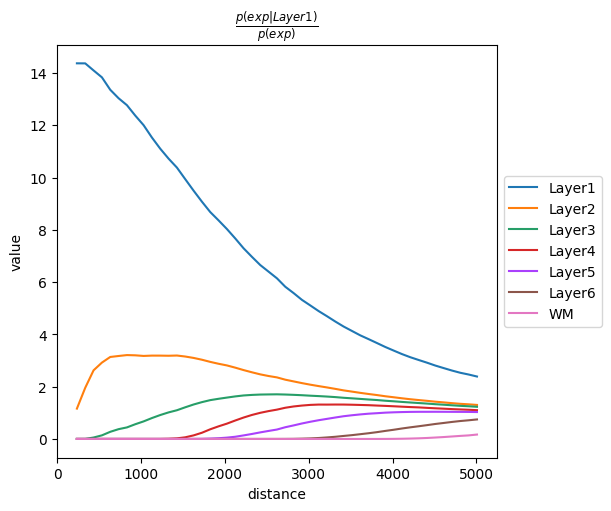

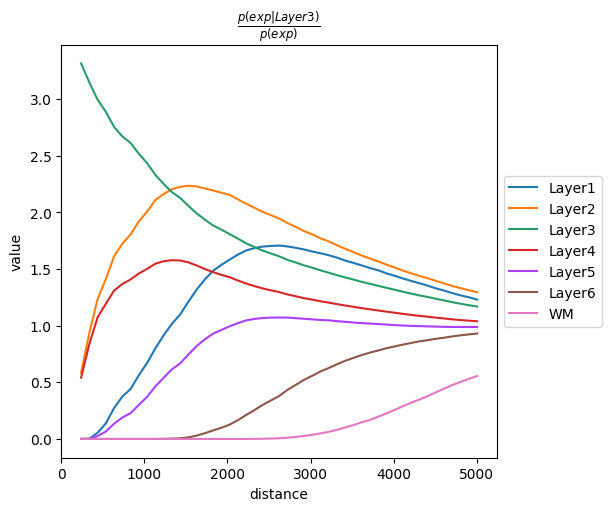

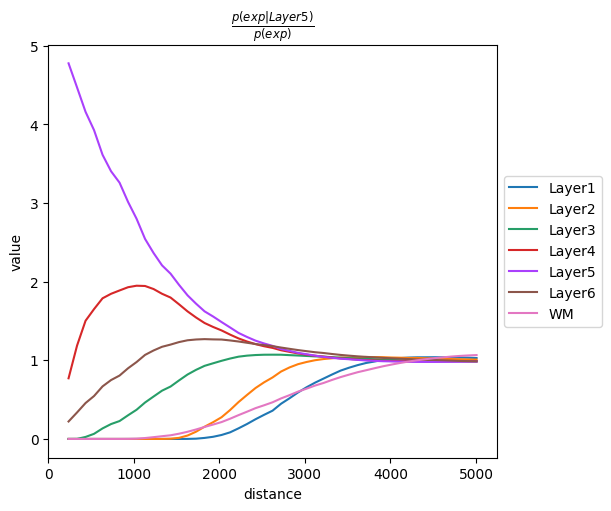

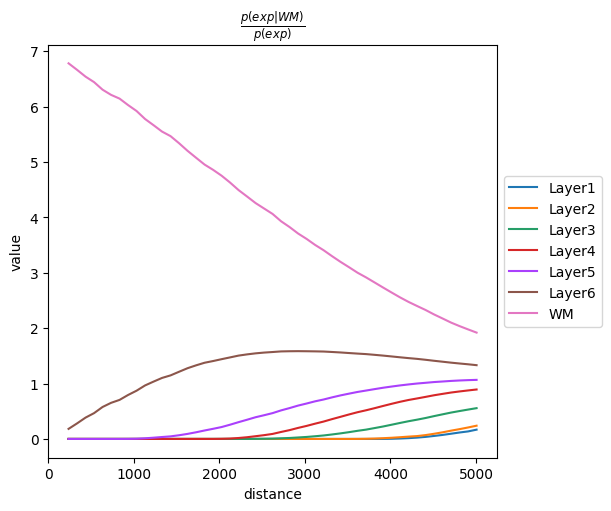

In [13]:
# Co-occurrence analysis
clusters_to_plot = ["Layer1", "Layer3", "Layer5", "WM"]

fig = plt.figure(figsize=(14, 12))
for i, cluster in enumerate(clusters_to_plot):
    sq.pl.co_occurrence(
        adata, cluster_key="ground_truth",
        clusters=cluster,
        figsize=(6, 5)
    )
    plt.savefig(os.path.join(figure_dir, f"co_occurrence_{cluster}.png"),
                dpi=200, bbox_inches='tight')
    plt.show()

In [10]:
# Ripley's L
sq.gr.ripley(adata, cluster_key="ground_truth", mode="L")

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
sq.pl.ripley(adata, cluster_key="ground_truth", mode="L",
             figsize=(10, 8), ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(figure_dir, "ripley_L.png"),
            dpi=200, bbox_inches='tight')
plt.close()

In [14]:
adata.write(os.path.join("../data/processed/06_adata_final.h5ad"))

/home/ec2-user/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_io/utils.py:272: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)
/home/ec2-user/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_io/utils.py:272: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)
/home/ec2-user/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_io/utils.py:272: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)
/home/ec2-user/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_io/utils.py:272: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)


In [15]:

print("obs columns:", adata.obs.columns.tolist())
print("obsm keys:", list(adata.obsm.keys()))
print("has raw:", adata.raw is not None)
print("has counts layer:", 'counts' in adata.layers)

obs columns: ['in_tissue', 'array_row', 'array_col', 'ground_truth', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes', 'leiden_0.3', 'leiden_0.5', 'leiden_0.55', 'leiden_0.6', 'leiden_0.65', 'leiden_0.7', 'leiden_0.58', 'leiden_0.62', 'leiden', 'spagcn_pred', 'spagcn_refined', 'bayesspace', 'uniform_density', 'rna_count_based_density', 'tangram_Astrocyte', 'tangram_Chandelier', 'tangram_L2/3 IT', 'tangram_L4 IT', 'tangram_L5/6 NP', 'tangram_L5 IT', 'tangram_L6 IT', 'tangram_L6 CT', 'tangram_Oligodendrocyte', 'tangram_Pax6', 'tangram_L6 IT Car3', 'tangram_L6b', 'tangram_Lamp5', 'tangram_Lamp5 Lhx6', 'tangram_Microglia-PVM', 'tangram_OPC', 'tangram_Sst', 'tangram_Vip', 'tangram_Pvalb', 'tangram_Sncg', 'tangram_L5 ET', 'tangram_Sst Chodl', 'tangram_VLMC', 'tangram_Endothelial']
obsm keys: ['X_pca', 'X_umap', 'spatial', 'tangram_ct_pred']
has raw: True
has counts layer: T